# Patient Churn Exploration

This notebook profiles the patient churn dataset, identifies the strongest churn patterns, and fits a simple baseline model to rank likely drivers.

Sections:
- load and validate the dataset
- inspect churn by category and numeric behavior
- create a few business-oriented derived features
- visualize the strongest patterns
- fit a baseline logistic regression model
- close with a concise findings summary


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
sns.set_theme(style='whitegrid', palette='Blues')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
RANDOM_STATE = 42


In [2]:
candidate_paths = [
    Path.cwd() / 'analysis' / 'patient_churn_dataset.csv',
    Path.cwd() / 'patient_churn_dataset.csv',
]

for path in candidate_paths:
    if path.exists():
        csv_path = path
        break
else:
    raise FileNotFoundError('Could not find patient_churn_dataset.csv')

df = pd.read_csv(csv_path)
print(f'Loaded {csv_path} with shape {df.shape}')
df.head()


Loaded /Users/devalshah/Documents/patient-churn/analysis/patient_churn_dataset.csv with shape (2000, 21)


,PatientID,Age,Gender,State,Tenure_Months,Specialty,Insurance_Type,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,Last_Interaction_Date,Overall_Satisfaction,Wait_Time_Satisfaction,Staff_Satisfaction,Provider_Rating,Avg_Out_Of_Pocket_Cost,Billing_Issues,Portal_Usage,Referrals_Made,Distance_To_Facility_Miles,Churned
0,C20000,41,Female,PA,62,Pediatrics,Medicaid,1,0,564,2024-07-05,3.5,4.9,3.8,4.2,306,0,0,3,21.4,1
1,C20001,43,Female,GA,44,Internal Medicine,Self-Pay,7,4,254,2025-05-11,2.6,3.1,4.7,4.3,1851,0,0,0,47.6,1
2,C20002,21,Male,MI,120,Internal Medicine,Medicaid,15,5,89,2025-10-23,1.6,4.4,2.1,4.7,391,0,0,2,7.1,0
3,C20003,65,Male,FL,118,General Practice,Private,10,3,135,2025-09-07,2.6,4.3,4.3,4.9,808,0,0,0,11.6,1
4,C20004,18,Female,CA,70,Cardiology,Medicaid,5,4,696,2024-02-24,2.2,4.0,4.1,4.4,866,0,0,0,10.3,1


## Data Preparation

In [3]:
df.columns = [c.strip().lower() for c in df.columns]
df['last_interaction_date'] = pd.to_datetime(df['last_interaction_date'])

numeric_cols = [
    'age', 'tenure_months', 'visits_last_year', 'missed_appointments',
    'days_since_last_visit', 'overall_satisfaction', 'wait_time_satisfaction',
    'staff_satisfaction', 'provider_rating', 'avg_out_of_pocket_cost',
    'referrals_made', 'distance_to_facility_miles'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['churned', 'billing_issues', 'portal_usage']:
    df[col] = df[col].astype(bool)

quality_summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_values': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
})

display(quality_summary)


,dtype,missing_values,missing_pct
patientid,object,0,0.0
age,int64,0,0.0
gender,object,0,0.0
state,object,0,0.0
tenure_months,int64,0,0.0
specialty,object,0,0.0
insurance_type,object,0,0.0
visits_last_year,int64,0,0.0
missed_appointments,int64,0,0.0
days_since_last_visit,int64,0,0.0


In [4]:
baseline_summary = pd.DataFrame({
    'rows': [len(df)],
    'unique_patients': [df['patientid'].nunique()],
    'churn_rate': [df['churned'].mean()],
    'avg_tenure_months': [df['tenure_months'].mean()],
    'avg_days_since_last_visit': [df['days_since_last_visit'].mean()],
})

baseline_summary.style.format({
    'churn_rate': '{:.1%}',
    'avg_tenure_months': '{:.1f}',
    'avg_days_since_last_visit': '{:.1f}',
})


,rows,unique_patients,churn_rate,avg_tenure_months,avg_days_since_last_visit
0,2000,2000,68.3%,60.7,366.1


## Churn by Category

In [5]:
def churn_by(frame, col, min_n=30):
    grouped = (
        frame.groupby(col, dropna=False, observed=False)
        .agg(n=('churned', 'size'), churn_rate=('churned', 'mean'))
        .sort_values(['churn_rate', 'n'], ascending=[False, False])
    )
    return grouped[grouped['n'] >= min_n]

category_tables = {}
for col in ['insurance_type', 'specialty', 'state', 'gender', 'portal_usage', 'billing_issues']:
    category_tables[col] = churn_by(df, col)
    print(f'\nChurn by {col}:')
    display(category_tables[col].style.format({'churn_rate': '{:.1%}'}))



Churn by insurance_type:


,n,churn_rate
insurance_type,,
Medicaid,478,70.5%
Private,483,69.4%
Self-Pay,523,67.1%
Medicare,516,66.7%



Churn by specialty:


,n,churn_rate
specialty,,
Neurology,286,70.3%
Family Medicine,289,70.2%
Pediatrics,284,69.7%
General Practice,302,69.5%
Internal Medicine,277,69.3%
Cardiology,273,65.2%
Orthopedics,289,64.0%



Churn by state:


...

,n,churn_rate
gender,,
Male,1016,69.0%
Female,984,67.7%



Churn by portal_usage:


,n,churn_rate
portal_usage,,
False,1588,70.1%
True,412,61.7%



Churn by billing_issues:


,n,churn_rate
billing_issues,,
True,157,77.1%
False,1843,67.6%


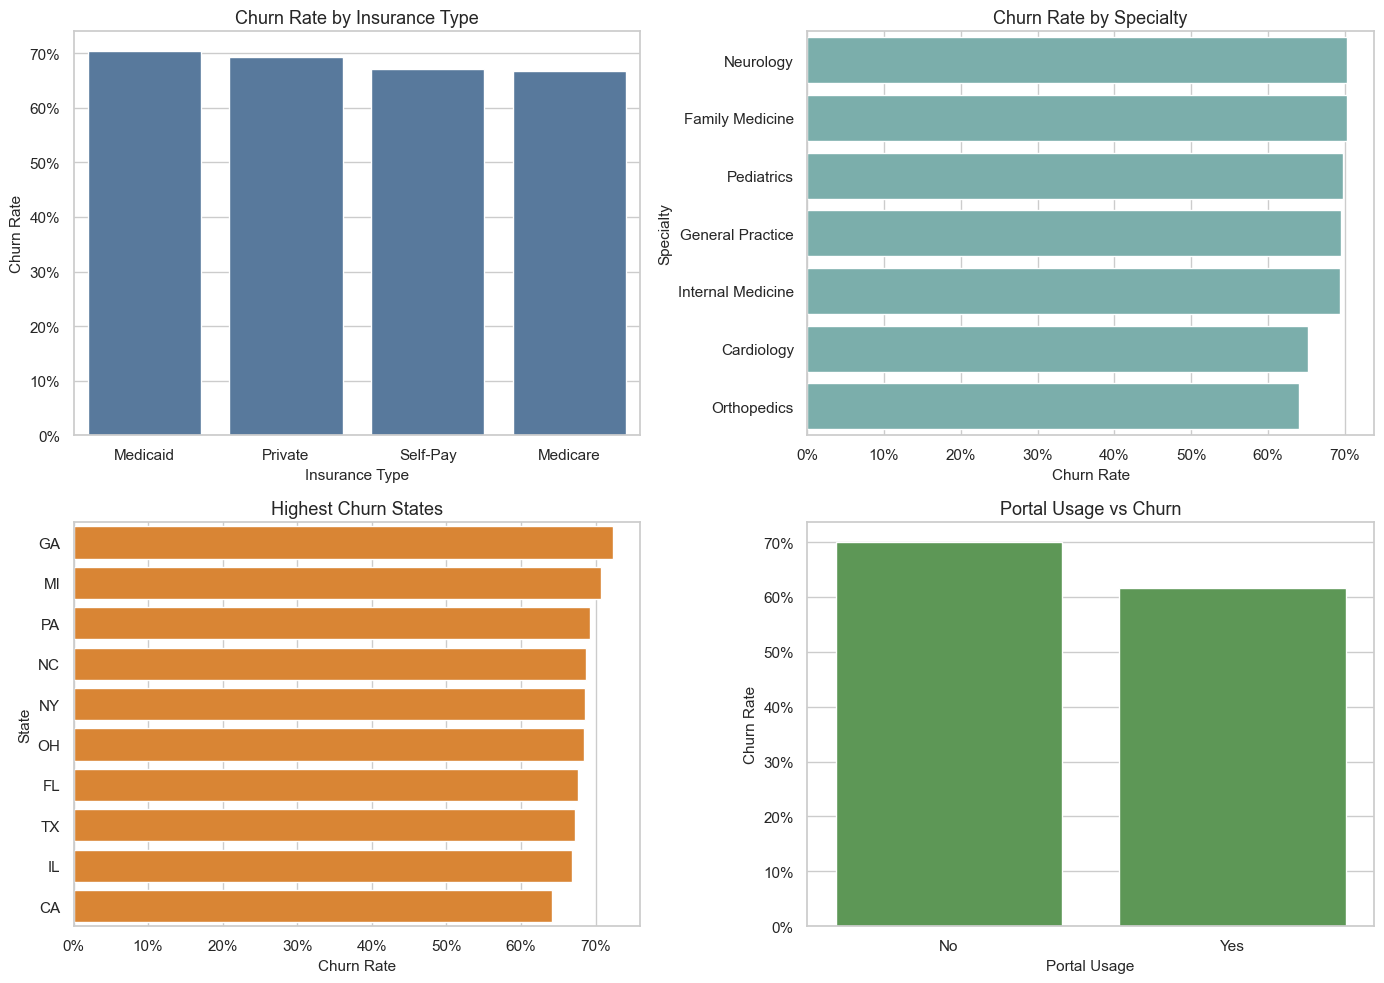

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

insurance_plot = category_tables['insurance_type'].reset_index()
sns.barplot(data=insurance_plot, x='insurance_type', y='churn_rate', ax=axes[0, 0], color='#4C78A8')
axes[0, 0].set_title('Churn Rate by Insurance Type')
axes[0, 0].set_xlabel('Insurance Type')
axes[0, 0].set_ylabel('Churn Rate')
axes[0, 0].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

specialty_plot = category_tables['specialty'].reset_index().head(7)
sns.barplot(data=specialty_plot, x='churn_rate', y='specialty', ax=axes[0, 1], color='#72B7B2')
axes[0, 1].set_title('Churn Rate by Specialty')
axes[0, 1].set_xlabel('Churn Rate')
axes[0, 1].set_ylabel('Specialty')
axes[0, 1].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

state_plot = category_tables['state'].reset_index().head(10)
sns.barplot(data=state_plot, x='churn_rate', y='state', ax=axes[1, 0], color='#F58518')
axes[1, 0].set_title('Highest Churn States')
axes[1, 0].set_xlabel('Churn Rate')
axes[1, 0].set_ylabel('State')
axes[1, 0].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

usage_plot = category_tables['portal_usage'].reset_index()
usage_plot['portal_usage'] = usage_plot['portal_usage'].map({False: 'No', True: 'Yes'})
sns.barplot(data=usage_plot, x='portal_usage', y='churn_rate', ax=axes[1, 1], color='#54A24B')
axes[1, 1].set_title('Portal Usage vs Churn')
axes[1, 1].set_xlabel('Portal Usage')
axes[1, 1].set_ylabel('Churn Rate')
axes[1, 1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()


## Numeric Driver Comparison

In [7]:
num_driver_cols = [
    'tenure_months', 'visits_last_year', 'missed_appointments',
    'days_since_last_visit', 'overall_satisfaction', 'wait_time_satisfaction',
    'staff_satisfaction', 'provider_rating', 'avg_out_of_pocket_cost',
    'referrals_made', 'distance_to_facility_miles'
]

numeric_summary = df.groupby('churned')[num_driver_cols].mean().T
numeric_summary.columns = ['not_churned_mean', 'churned_mean']
numeric_summary['diff'] = numeric_summary['churned_mean'] - numeric_summary['not_churned_mean']
numeric_summary = numeric_summary.sort_values('diff', ascending=False)
display(numeric_summary.round(3))


,not_churned_mean,churned_mean,diff
avg_out_of_pocket_cost,787.735,859.146,71.411
days_since_last_visit,339.141,378.628,39.487
distance_to_facility_miles,23.627,25.881,2.254
visits_last_year,7.259,7.778,0.519
missed_appointments,1.855,2.108,0.254
staff_satisfaction,3.485,3.545,0.059
provider_rating,3.794,3.709,-0.085
referrals_made,1.548,1.454,-0.095
wait_time_satisfaction,3.407,3.236,-0.172
overall_satisfaction,3.483,3.149,-0.334


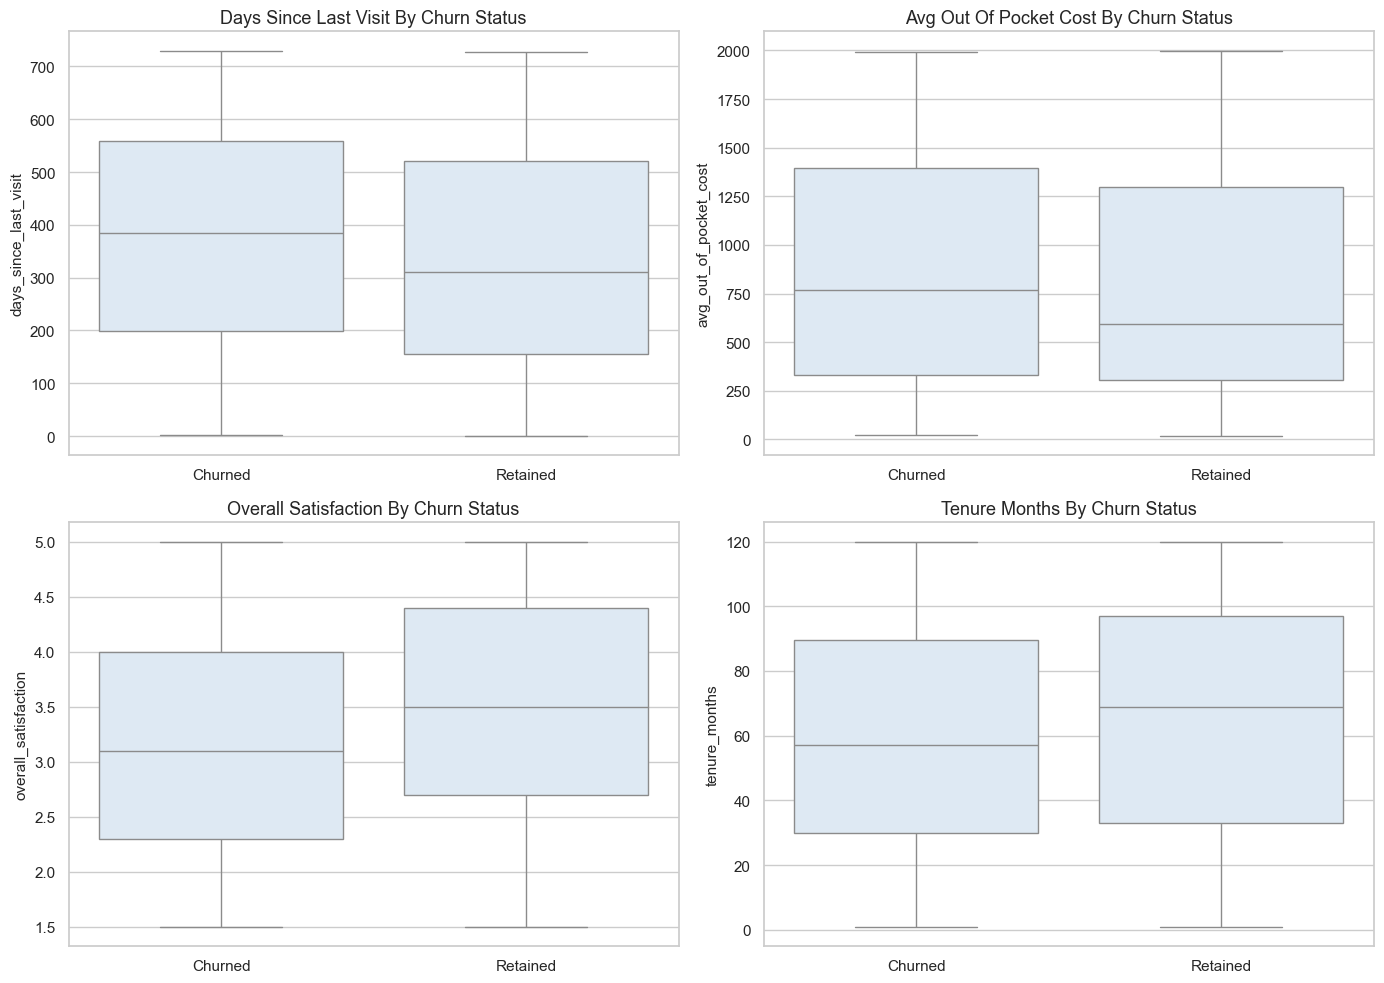

In [8]:
plot_cols = ['days_since_last_visit', 'avg_out_of_pocket_cost', 'overall_satisfaction', 'tenure_months']
plot_frame = df[plot_cols + ['churned']].copy()
plot_frame['churn_status'] = plot_frame['churned'].map({False: 'Retained', True: 'Churned'})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, plot_cols):
    sns.boxplot(data=plot_frame, x='churn_status', y=col, ax=ax)
    ax.set_title(f'{col} by churn status'.replace('_', ' ').title())
    ax.set_xlabel('')

plt.tight_layout()
plt.show()


## Derived Features

In [9]:
df['satisfaction_composite'] = df[[
    'overall_satisfaction', 'wait_time_satisfaction', 'staff_satisfaction', 'provider_rating'
]].mean(axis=1)

df['missed_rate'] = df['missed_appointments'] / (df['visits_last_year'] + df['missed_appointments'])
df.loc[(df['visits_last_year'] + df['missed_appointments']) == 0, 'missed_rate'] = np.nan

df['tenure_bucket'] = pd.cut(
    df['tenure_months'],
    bins=[-1, 11, 23, 59, 95, np.inf],
    labels=['00-11', '12-23', '24-59', '60-95', '96+']
)

df['age_bucket'] = pd.cut(
    df['age'],
    bins=[-1, 24, 34, 44, 54, 64, np.inf],
    labels=['<25', '25-34', '35-44', '45-54', '55-64', '65+']
)

df['sat_q'] = pd.qcut(df['satisfaction_composite'], 4, duplicates='drop')

tenure_churn = (
    df.groupby('tenure_bucket', observed=False)
    .agg(n=('churned', 'size'), churn_rate=('churned', 'mean'))
    .reset_index()
)

satisfaction_churn = (
    df.groupby('sat_q', observed=False)
    .agg(n=('churned', 'size'), churn_rate=('churned', 'mean'))
    .reset_index()
)

display(tenure_churn.style.format({'churn_rate': '{:.1%}'}))
display(satisfaction_churn.style.format({'churn_rate': '{:.1%}'}))


,tenure_bucket,n,churn_rate
0,00-11,180,75.6%
1,12-23,206,68.4%
2,24-59,599,72.0%
3,60-95,570,65.8%
4,96+,445,63.8%


,sat_q,n,churn_rate
0,"(1.999, 3.125]",513,78.0%
1,"(3.125, 3.45]",513,69.8%
2,"(3.45, 3.775]",476,65.8%
3,"(3.775, 4.75]",498,59.4%


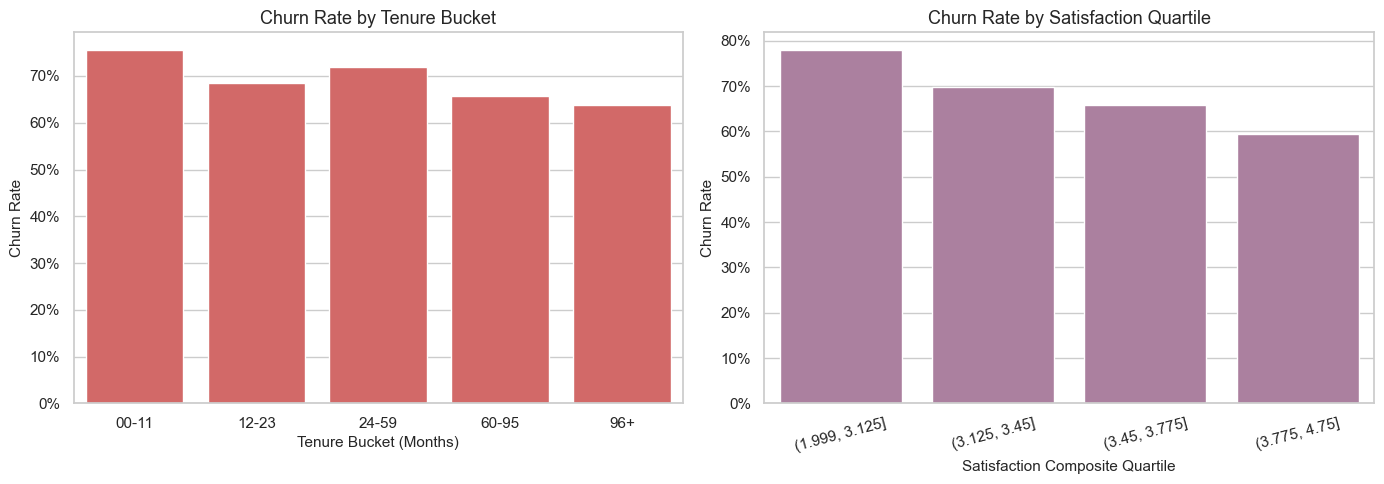

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=tenure_churn, x='tenure_bucket', y='churn_rate', ax=axes[0], color='#E45756')
axes[0].set_title('Churn Rate by Tenure Bucket')
axes[0].set_xlabel('Tenure Bucket (Months)')
axes[0].set_ylabel('Churn Rate')
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

sat_plot = satisfaction_churn.copy()
sat_plot['sat_q'] = sat_plot['sat_q'].astype(str)
sns.barplot(data=sat_plot, x='sat_q', y='churn_rate', ax=axes[1], color='#B279A2')
axes[1].set_title('Churn Rate by Satisfaction Quartile')
axes[1].set_xlabel('Satisfaction Composite Quartile')
axes[1].set_ylabel('Churn Rate')
axes[1].tick_params(axis='x', rotation=15)
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()


## Baseline Model

In [11]:
model_df = df.copy()
model_df['churned'] = model_df['churned'].astype(int)
model_df['billing_issues'] = model_df['billing_issues'].astype(int)
model_df['portal_usage'] = model_df['portal_usage'].astype(int)

X = model_df.drop(columns=['churned', 'patientid', 'last_interaction_date'])
y = model_df['churned']

numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = [col for col in X.columns if col not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore')),
            ]),
            categorical_features,
        ),
    ]
)

logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
])

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

logistic_model.fit(X_train, y_train)
y_pred = logistic_model.predict(X_test)
y_score = logistic_model.predict_proba(X_test)[:, 1]

holdout_metrics = pd.DataFrame({
    'metric': ['accuracy', 'roc_auc', 'test_rows'],
    'value': [accuracy_score(y_test, y_pred), roc_auc_score(y_test, y_score), len(y_test)],
})
display(holdout_metrics)

conf_mat = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=['actual_0', 'actual_1'],
    columns=['pred_0', 'pred_1']
)
display(conf_mat)


,metric,value
0,accuracy,0.594000
1,roc_auc,0.604875
2,test_rows,500.000000


,pred_0,pred_1
actual_0,90,68
actual_1,135,207


In [12]:
feature_names = logistic_model.named_steps['preprocessor'].get_feature_names_out()
logistic_coefficients = logistic_model.named_steps['classifier'].coef_[0]
logistic_feature_importance = (
    pd.DataFrame({'feature': feature_names, 'coefficient': logistic_coefficients})
    .assign(abs_coefficient=lambda x: x['coefficient'].abs())
    .sort_values('abs_coefficient', ascending=False)
)

top_risk_features = logistic_feature_importance.sort_values('coefficient', ascending=False).head(10)
top_retention_features = logistic_feature_importance.sort_values('coefficient', ascending=True).head(10)

display(top_risk_features[['feature', 'coefficient']].round(3))
display(top_retention_features[['feature', 'coefficient']].round(3))


,feature,coefficient
50,"cat__sat_q_(1.999, 3.125]",0.488
49,cat__age_bucket_<25,0.291
9,num__avg_out_of_pocket_cost,0.246
3,num__missed_appointments,0.246
4,num__days_since_last_visit,0.242
44,cat__age_bucket_25-34,0.238
7,num__staff_satisfaction,0.215
39,cat__tenure_bucket_00-11,0.210
45,cat__age_bucket_35-44,0.207
13,num__distance_to_facility_miles,0.184


,feature,coefficient
53,"cat__sat_q_(3.775, 4.75]",-0.346
47,cat__age_bucket_55-64,-0.333
5,num__overall_satisfaction,-0.225
46,cat__age_bucket_45-54,-0.190
42,cat__tenure_bucket_60-95,-0.179
23,cat__state_NC,-0.161
12,num__referrals_made,-0.155
48,cat__age_bucket_65+,-0.141
11,num__portal_usage,-0.139
38,cat__insurance_type_Self-Pay,-0.134


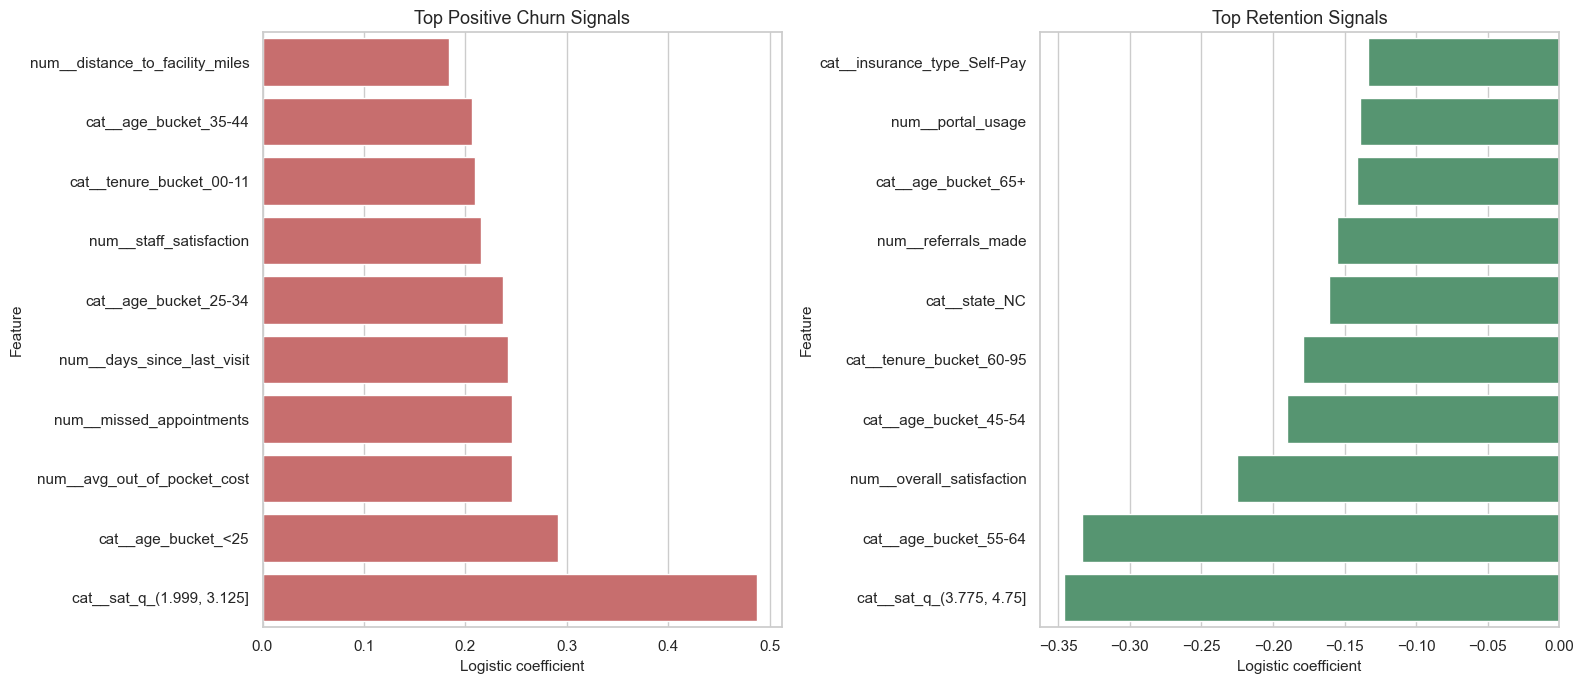

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

risk_plot = top_risk_features.sort_values('coefficient', ascending=True)
sns.barplot(data=risk_plot, x='coefficient', y='feature', ax=axes[0], color='#D65F5F')
axes[0].set_title('Top Positive Churn Signals')
axes[0].set_xlabel('Logistic coefficient')
axes[0].set_ylabel('Feature')

retention_plot = top_retention_features.sort_values('coefficient', ascending=False)
sns.barplot(data=retention_plot, x='coefficient', y='feature', ax=axes[1], color='#4C9F70')
axes[1].set_title('Top Retention Signals')
axes[1].set_xlabel('Logistic coefficient')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()


## Model Validation

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'accuracy': 'accuracy', 'roc_auc': 'roc_auc'}

validation_rows = []
for model_name, candidate in {
    'logistic_regression': logistic_model,
    'random_forest': rf_model,
}.items():
    scores = cross_validate(candidate, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    validation_rows.append({
        'model': model_name,
        'cv_accuracy_mean': scores['test_accuracy'].mean(),
        'cv_accuracy_std': scores['test_accuracy'].std(),
        'cv_roc_auc_mean': scores['test_roc_auc'].mean(),
        'cv_roc_auc_std': scores['test_roc_auc'].std(),
    })

validation_summary = pd.DataFrame(validation_rows).sort_values('cv_roc_auc_mean', ascending=False)
display(validation_summary.round(3))


,model,cv_accuracy_mean,cv_accuracy_std,cv_roc_auc_mean,cv_roc_auc_std
0,logistic_regression,0.616,0.008,0.641,0.019
1,random_forest,0.691,0.006,0.636,0.018


In [15]:
rf_model.fit(X_train, y_train)
rf_score = rf_model.predict_proba(X_test)[:, 1]
rf_holdout_auc = roc_auc_score(y_test, rf_score)
print(f'Random forest holdout ROC AUC: {rf_holdout_auc:.3f}')

rf_feature_importance = pd.DataFrame({
    'feature': rf_model.named_steps['preprocessor'].get_feature_names_out(),
    'importance': rf_model.named_steps['classifier'].feature_importances_,
}).sort_values('importance', ascending=False)

display(rf_feature_importance.head(15).round(4))


Random forest holdout ROC AUC: 0.612


,feature,importance
4,num__days_since_last_visit,0.0807
5,num__overall_satisfaction,0.0796
13,num__distance_to_facility_miles,0.0744
9,num__avg_out_of_pocket_cost,0.0693
1,num__tenure_months,0.0667
14,num__satisfaction_composite,0.0635
7,num__staff_satisfaction,0.0567
0,num__age,0.0559
6,num__wait_time_satisfaction,0.0480
8,num__provider_rating,0.0474


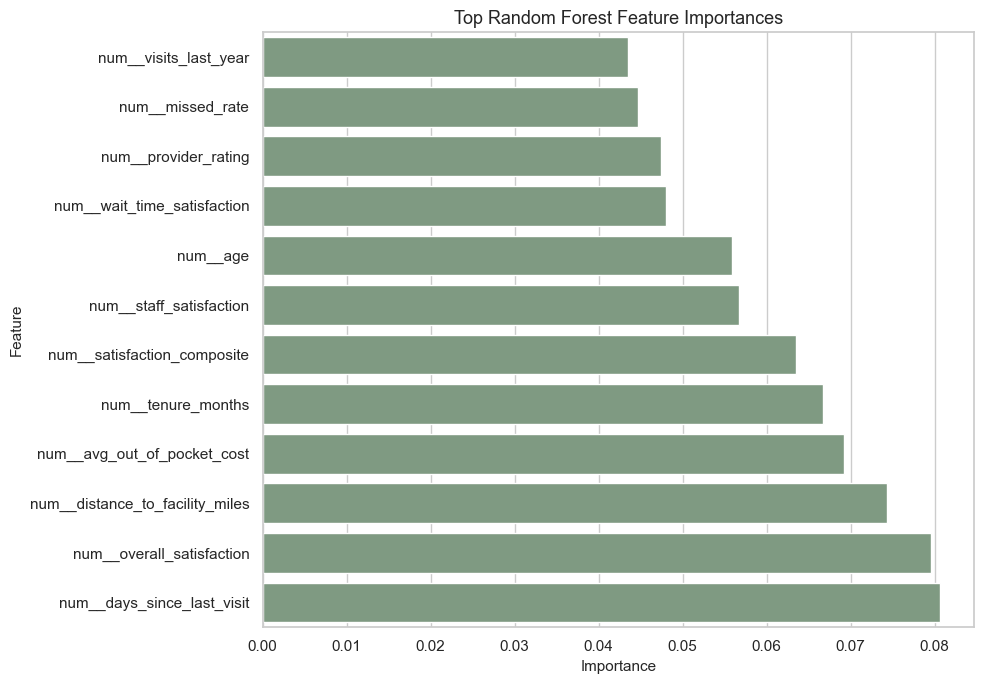

In [16]:
rf_plot = rf_feature_importance.head(12).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 7))
sns.barplot(data=rf_plot, x='importance', y='feature', color='#7A9E7E')
plt.title('Top Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## Findings Summary

In [17]:
highest_insurance = category_tables['insurance_type']['churn_rate'].idxmax()
highest_insurance_rate = category_tables['insurance_type'].loc[highest_insurance, 'churn_rate']
portal_gap = category_tables['portal_usage']['churn_rate'].max() - category_tables['portal_usage']['churn_rate'].min()
billing_gap = category_tables['billing_issues']['churn_rate'].max() - category_tables['billing_issues']['churn_rate'].min()
short_tenure_rate = tenure_churn.loc[tenure_churn['tenure_bucket'] == '00-11', 'churn_rate'].iloc[0]
long_tenure_rate = tenure_churn.loc[tenure_churn['tenure_bucket'] == '96+', 'churn_rate'].iloc[0]
low_sat_rate = satisfaction_churn['churn_rate'].max()
high_sat_rate = satisfaction_churn['churn_rate'].min()
best_cv_row = validation_summary.iloc[0]

print('Key findings')
print(f"- Baseline churn is {df['churned'].mean():.1%}, so churn is the majority outcome in this dataset.")
print(f"- {highest_insurance} has the highest insurance-level churn at {highest_insurance_rate:.1%}.")
print(f"- Patients without portal usage churn {portal_gap:.1%} more often than portal users.")
print(f"- Billing issues correspond to a {billing_gap:.1%} higher churn rate.")
print(f"- Short-tenure patients (00-11 months) churn at {short_tenure_rate:.1%} versus {long_tenure_rate:.1%} for patients with 96+ months tenure.")
print(f"- Satisfaction matters: the highest-risk satisfaction quartile churns at {low_sat_rate:.1%} versus {high_sat_rate:.1%} in the lowest-risk quartile.")
print(f"- Logistic regression reaches holdout ROC AUC {roc_auc_score(y_test, y_score):.3f}; the best cross-validated model is {best_cv_row['model']} at ROC AUC {best_cv_row['cv_roc_auc_mean']:.3f}.")
print('- Strong positive churn signals include younger age buckets, high out-of-pocket cost, missed appointments, long gaps since the last visit, and billing issues.')
print('- Cross-validated tree-based importance reinforces tenure, recency of visits, cost burden, satisfaction, and missed appointments as the main operational levers.')
print('- These results are useful for prioritization, but model quality is still modest, so this should not be treated as a production scoring pipeline.')


Key findings
- Baseline churn is 68.3%, so churn is the majority outcome in this dataset.
- Medicaid has the highest insurance-level churn at 70.5%.
- Patients without portal usage churn 8.4% more often than portal users.
- Billing issues correspond to a 9.5% higher churn rate.
- Short-tenure patients (00-11 months) churn at 75.6% versus 63.8% for patients with 96+ months tenure.
- Satisfaction matters: the highest-risk satisfaction quartile churns at 78.0% versus 59.4% in the lowest-risk quartile.
- Logistic regression reaches holdout ROC AUC 0.605; the best cross-validated model is logistic_regression at ROC AUC 0.641.
- Strong positive churn signals include younger age buckets, high out-of-pocket cost, missed appointments, long gaps since the last visit, and billing issues.
- Cross-validated tree-based importance reinforces tenure, recency of visits, cost burden, satisfaction, and missed appointments as the main operational levers.
- These results are useful for prioritization, but 